# Lab Work: Developing and Comparing AI Models for Android Malware Detection

## Objective:
The goal of this lab is to develop and evaluate multiple AI models for detecting Android malware using the provided Android Malware Dataset. Students will choose at least three different machine learning or deep learning algorithms to compare their performance in classifying Android applications as benign or malicious.

## Dataset Overview:
The **Android Malware Dataset for Machine Learning** contains labeled Android APK samples, classified as benign (goodware) or malicious (e.g., adware, spyware, trojans). It includes various features extracted from the APKs, such as requested permissions, API calls, system behaviors, and more, which can be used to train machine learning models.

## Tasks:

1. **Data Preprocessing**:
   - Load the dataset and clean it by handling missing values and converting categorical features into numerical ones if necessary.
   - Split the data into training and testing sets.

2. **Model Development**:
   - Choose at least **three AI algorithms** of your choice (e.g., Logistic Regression, Random Forest, SVM, Neural Networks, XGBoost, etc.).
   - Train each model on the dataset and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrix.

3. **Model Comparison**:
   - Compare the models based on their performance metrics.
   - Analyze which model performs best and why.

4. **Optional (Hyperparameter Tuning)**:
   - Optionally, apply techniques like grid search to optimize the model’s hyperparameters.


## Resources:
- Kaggle Dataset: [Android Malware Dataset for Machine Learning](https://www.kaggle.com/datasets/shashwatwork/android-malware-dataset-for-machine-learning)

You need to login in Kaggle to get access to the dataset.


In [13]:
!pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   - -------------------------------------- 7.3/150.0 MB 37.8 MB/s eta 0:00:04
   ---- ----------------------------------- 16.0/150.0 MB 40.3 MB/s eta 0:00:04
   ------ --------------------------------- 23.3/150.0 MB 38.9 MB/s eta 0:00:04
   ------- -------------------------------- 29.4/150.0 MB 37.3 MB/s eta 0:00:04
   -------- ------------------------------- 30.4/150.0 MB 33.3 MB/s eta 0:00:04
   -------- ------------------------------- 31.7/150.0 MB 25.5 MB/s eta 0:00:05
   ---------- ----------------------------- 38.8/150.0 MB 26.5 MB/s eta 0:00:05
   ----------- ---------------------------- 44.8/150.0 MB 27.7 MB/s eta 0:00:04
   ----------- ---------------------------- 44.8/150.0 MB 27.7 MB/s eta 0:00:04
   ------------ --------------------------- 46.9/150.0 MB 23.7 MB/s eta 0:00:05
   ------------ --------------------------- 46.9/150.0 MB 23.7 MB/s eta 0:00:05
   ------------ --------------------------- 46.9/1

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# STEP 1: Load dataset safely
df = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv", low_memory=False)

# STEP 2: Print columns to identify the target label column
print("Columns:", df.columns.tolist())

# STEP 3: Rename label column if needed (manually adjust this based on actual column name)
# For example, if the label column is 'class', rename it to 'label'
if 'class' in df.columns:
    df.rename(columns={'class': 'label'}, inplace=True)
elif 'malware' in df.columns:
    df.rename(columns={'malware': 'label'}, inplace=True)

# STEP 4: Convert all object/mixed-type columns to string
for col in df.columns:
    if df[col].apply(type).nunique() > 1:
        df[col] = df[col].astype(str)

# STEP 5: Encode all categorical (object/string) columns
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

# STEP 6: Separate features and label
if 'label' not in df.columns:
    raise ValueError("Target label column not found. Check your dataset.")

X = df.drop('label', axis=1)
y = df['label']

# STEP 7: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 8: Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# STEP 9: Train and evaluate models
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }

# STEP 10: Print results
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    for metric_name, value in metrics.items():
        if metric_name != "Confusion Matrix":
            print(f"{metric_name}: {value:.4f}")
        else:
            print(f"{metric_name}:\n{value}")
    print("-" * 40)



Columns: ['transact', 'onServiceConnected', 'bindService', 'attachInterface', 'ServiceConnection', 'android.os.Binder', 'SEND_SMS', 'Ljava.lang.Class.getCanonicalName', 'Ljava.lang.Class.getMethods', 'Ljava.lang.Class.cast', 'Ljava.net.URLDecoder', 'android.content.pm.Signature', 'android.telephony.SmsManager', 'READ_PHONE_STATE', 'getBinder', 'ClassLoader', 'Landroid.content.Context.registerReceiver', 'Ljava.lang.Class.getField', 'Landroid.content.Context.unregisterReceiver', 'GET_ACCOUNTS', 'RECEIVE_SMS', 'Ljava.lang.Class.getDeclaredField', 'READ_SMS', 'getCallingUid', 'Ljavax.crypto.spec.SecretKeySpec', 'android.intent.action.BOOT_COMPLETED', 'USE_CREDENTIALS', 'MANAGE_ACCOUNTS', 'android.content.pm.PackageInfo', 'KeySpec', 'TelephonyManager.getLine1Number', 'DexClassLoader', 'HttpGet.init', 'SecretKey', 'Ljava.lang.Class.getMethod', 'System.loadLibrary', 'android.intent.action.SEND', 'Ljavax.crypto.Cipher', 'WRITE_SMS', 'READ_SYNC_SETTINGS', 'AUTHENTICATE_ACCOUNTS', 'android.telep

C:\Users\durge\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:21:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: Logistic Regression
Accuracy: 0.9784
Precision: 0.9746
Recall: 0.9667
F1-score: 0.9707
Confusion Matrix:
[[1868   28]
 [  37 1075]]
----------------------------------------

Model: Random Forest
Accuracy: 0.9887
Precision: 0.9909
Recall: 0.9784
F1-score: 0.9846
Confusion Matrix:
[[1886   10]
 [  24 1088]]
----------------------------------------

Model: XGBoost
Accuracy: 0.9890
Precision: 0.9900
Recall: 0.9802
F1-score: 0.9851
Confusion Matrix:
[[1885   11]
 [  22 1090]]
----------------------------------------


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# Train and evaluate each model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "Confusion Matrix": confusion_matrix(y_test, y_pred)
    }


C:\Users\durge\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [04:23:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [19]:
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    for metric_name, value in metrics.items():
        if metric_name != "Confusion Matrix":
            print(f"{metric_name}: {value:.4f}")
        else:
            print(f"{metric_name}:\n{value}")
    print("-" * 30)


Model: Logistic Regression
Accuracy: 0.9784
Precision: 0.9746
Recall: 0.9667
F1-score: 0.9707
Confusion Matrix:
[[1868   28]
 [  37 1075]]
------------------------------
Model: Random Forest
Accuracy: 0.9887
Precision: 0.9909
Recall: 0.9784
F1-score: 0.9846
Confusion Matrix:
[[1886   10]
 [  24 1088]]
------------------------------
Model: XGBoost
Accuracy: 0.9890
Precision: 0.9900
Recall: 0.9802
F1-score: 0.9851
Confusion Matrix:
[[1885   11]
 [  22 1090]]
------------------------------


**Lab Logbook requirement**: Provide a graph comparing the performance of the AI model that you have developed.

Columns: ['transact', 'onServiceConnected', 'bindService', 'attachInterface', 'ServiceConnection', 'android.os.Binder', 'SEND_SMS', 'Ljava.lang.Class.getCanonicalName', 'Ljava.lang.Class.getMethods', 'Ljava.lang.Class.cast', 'Ljava.net.URLDecoder', 'android.content.pm.Signature', 'android.telephony.SmsManager', 'READ_PHONE_STATE', 'getBinder', 'ClassLoader', 'Landroid.content.Context.registerReceiver', 'Ljava.lang.Class.getField', 'Landroid.content.Context.unregisterReceiver', 'GET_ACCOUNTS', 'RECEIVE_SMS', 'Ljava.lang.Class.getDeclaredField', 'READ_SMS', 'getCallingUid', 'Ljavax.crypto.spec.SecretKeySpec', 'android.intent.action.BOOT_COMPLETED', 'USE_CREDENTIALS', 'MANAGE_ACCOUNTS', 'android.content.pm.PackageInfo', 'KeySpec', 'TelephonyManager.getLine1Number', 'DexClassLoader', 'HttpGet.init', 'SecretKey', 'Ljava.lang.Class.getMethod', 'System.loadLibrary', 'android.intent.action.SEND', 'Ljavax.crypto.Cipher', 'WRITE_SMS', 'READ_SYNC_SETTINGS', 'AUTHENTICATE_ACCOUNTS', 'android.telep

<Figure size 1000x600 with 0 Axes>

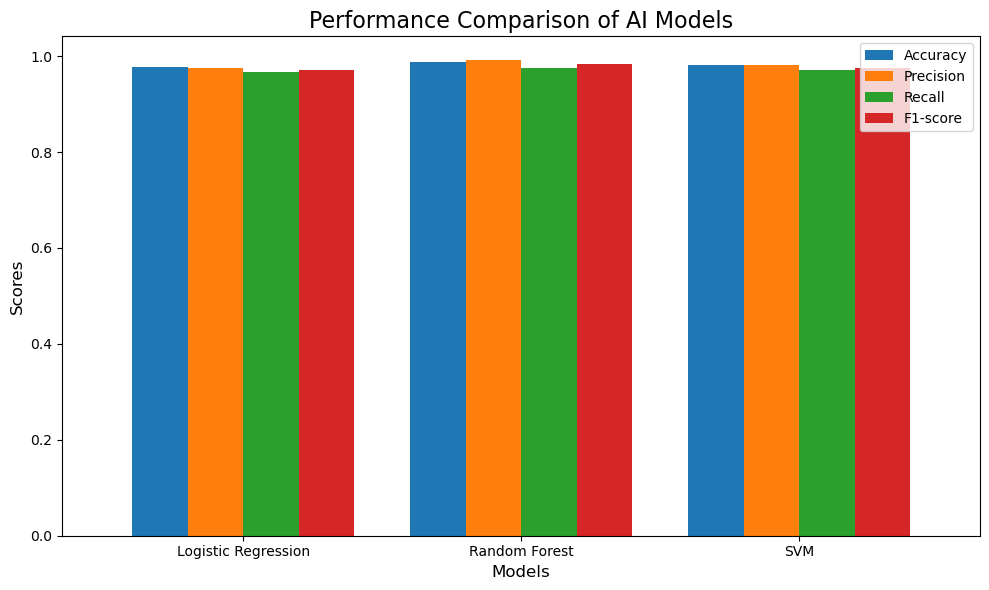

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# STEP 1: Load dataset safely
df = pd.read_csv("drebin-215-dataset-5560malware-9476-benign.csv", low_memory=False)

# STEP 2: Print columns to identify the target label column
print("Columns:", df.columns.tolist())

# STEP 3: Rename label column if needed (adjust as per your actual column)
if 'class' in df.columns:
    df.rename(columns={'class': 'label'}, inplace=True)
elif 'malware' in df.columns:
    df.rename(columns={'malware': 'label'}, inplace=True)

# STEP 4: Convert all mixed-type columns to string
for col in df.columns:
    if df[col].apply(type).nunique() > 1:
        df[col] = df[col].astype(str)

# STEP 5: Encode all categorical columns
label_encoders = {}
for column in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column].astype(str))
    label_encoders[column] = le

# STEP 6: Separate features and label
if 'label' not in df.columns:
    raise ValueError("Target label column not found. Check your dataset.")

X = df.drop('label', axis=1)
y = df['label']

# STEP 7: Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 8: Initialize models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC()
}

# STEP 9: Train and evaluate models
results = {
    "Model": [],
    "Accuracy": [],
    "Precision": [],
    "Recall": [],
    "F1-score": []
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    results["Model"].append(name)
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred))
    results["Recall"].append(recall_score(y_test, y_pred))
    results["F1-score"].append(f1_score(y_test, y_pred))

# STEP 10: Plot comparison graph
df_results = pd.DataFrame(results)

# Set the figure size
plt.figure(figsize=(10, 6))

# Plotting Accuracy, Precision, Recall, and F1-score
df_results.set_index('Model').plot(kind='bar', figsize=(10, 6), width=0.8)

# Adding labels and title
plt.title('Performance Comparison of AI Models', fontsize=16)
plt.ylabel('Scores', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()

# Show the graph
plt.show()
